# Comprehensive Dataset Analysis
This notebook provides a step-by-step analysis of the train, validation, and test datasets for temporal graph neural networks. We will explore adjacency matrix properties, node features, homophily, up ratios, and more.

In [1]:
# Import required libraries
from dataset_analyzer import MarketAnalyzer
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Datasets
We load the train, validation, and test datasets using the MarketAnalyzer class.

In [2]:
MARKET = 'NYSE'
NORMALIZATION = 'zscore'
WINDOW_SIZE = 22

train_path = Path(f"/home/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/{MARKET}_Train_2016-05-01_2017-06-30_{WINDOW_SIZE}_{NORMALIZATION}")
val_path = Path(f"/home/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/{MARKET}_Validation_2017-07-01_2017-12-31_{WINDOW_SIZE}_{NORMALIZATION}")
test_path = Path(f"/home/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/{MARKET}_Test_2018-01-01_2019-12-31_{WINDOW_SIZE}_{NORMALIZATION}")

train_analyzer = MarketAnalyzer(train_path)
val_analyzer = MarketAnalyzer(val_path)
test_analyzer = MarketAnalyzer(test_path)

|             Dataset Information             |
| Market Name:         NYSE                    |
| Time Period:         Train                   |
| Start Date:          2016-05-01              |
| End Date:            2017-06-30              |
| Window Size:         22                      |
| Normalizer:          zscore                  |
| Number of Features:  5                       |
| Number of Nodes:     1171                    |
| Number of Snapshots: 219                     |
Folder analysis_results already exists at /home/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/NYSE_Train_2016-05-01_2017-06-30_22_zscore
|             Dataset Information             |
| Market Name:         NYSE                    |
| Time Period:         Validation              |
| Start Date:          2017-07-01              |
| End Date:            2017-12-31              |
| Window Size:         22                      |
| Normalizer:          zscore                  |
| Number of Features

## Extract Snapshots Info
Get snapshot-level information for each dataset.

In [3]:
train_snapshots_info = train_analyzer.get_snapshots_info()
val_snapshots_info = val_analyzer.get_snapshots_info()
test_snapshots_info = test_analyzer.get_snapshots_info()

train_df = pd.DataFrame(train_snapshots_info)
train_df['dataset'] = 'train'
val_df = pd.DataFrame(val_snapshots_info)
val_df['dataset'] = 'validation'
test_df = pd.DataFrame(test_snapshots_info)
test_df['dataset'] = 'test'
all_snapshots_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

## Adjacency Matrix Analysis
Analyze properties of the adjacency matrices: density, connectivity, and degree distribution.

## Adjacency Matrix Values Legend
In our graph representation:
- **Edge weights**: Represent the correlation strength between stock price movements
- **0 values**: No edge between nodes (no significant correlation)
- **Positive values**: Positive correlation between stock price movements
- **Higher values**: Stronger correlation between stocks

The adjacency matrix is a key component that shows relationships between different stocks in the market graph.

Adjacency matrix shape: (1171, 1171)


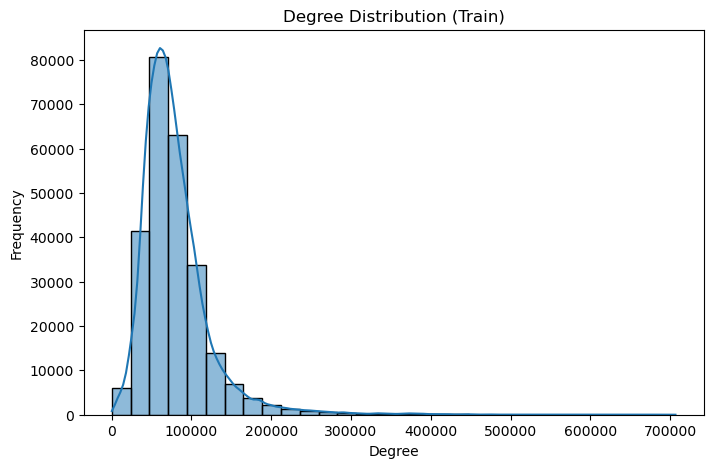

In [ ]:
adj_matrices = train_analyzer.get_snapshots_adjacency_matrix()
degrees = []
for adj in adj_matrices:
        deg = np.sum(adj, axis=1)
        degrees.extend(deg)
plt.figure(figsize=(8, 5))
sns.histplot(degrees, bins=30, kde=True)
plt.title('Degree Distribution (Train)')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.show()

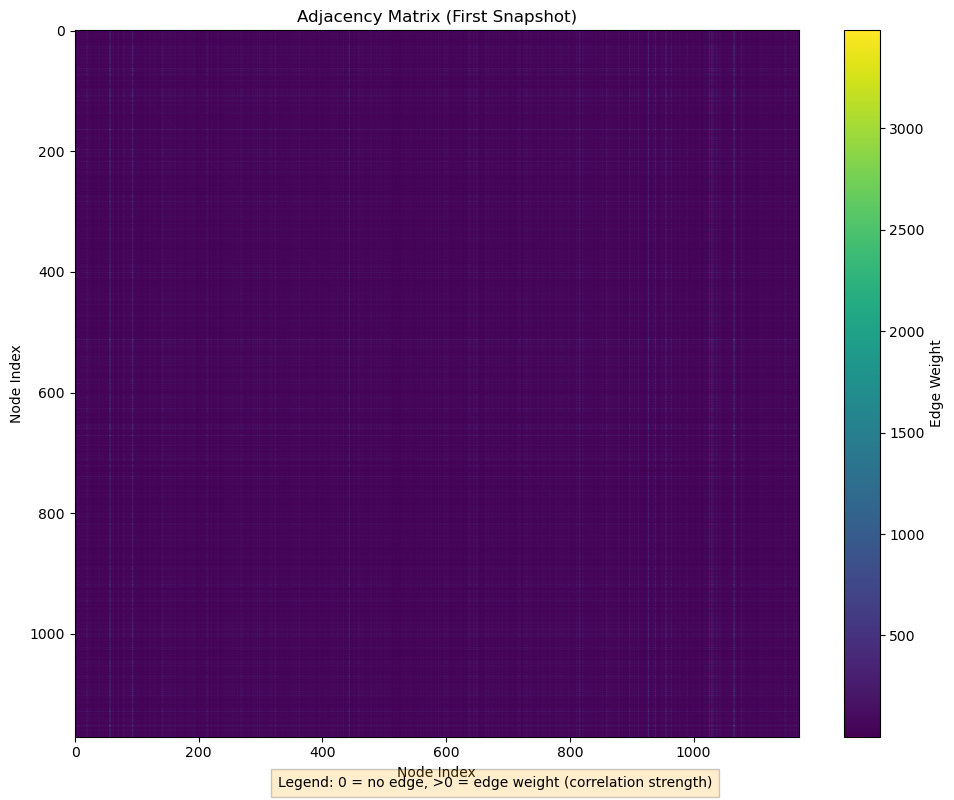

: 

In [ ]:
# Display the adjacency matrix with colorbar and legend
plt.figure(figsize=(10, 8))
im = plt.imshow(adj_matrices[0], cmap='viridis', aspect='auto')
plt.title('Adjacency Matrix (First Snapshot)')
plt.xlabel('Node Index')
plt.ylabel('Node Index')
plt.colorbar(im, label='Edge Weight')
plt.figtext(0.5, 0.01, "Legend: 0 = no edge, >0 = edge weight (correlation strength)", 
           ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
plt.tight_layout()
plt.show()

In [ ]:
# Analyze distribution of adjacency matrix values (edge weights)
edge_weights = []
for adj in adj_matrices:
    # Get only the non-zero values (actual edges)
    non_zero_weights = adj[adj > 0]
    if len(non_zero_weights) > 0:
        edge_weights.extend(non_zero_weights)

plt.figure(figsize=(10, 6))
sns.histplot(edge_weights, bins=100, kde=True)
plt.title('Edge Weight Distribution in Adjacency Matrices (Train)')
plt.xlabel('Edge Weight')
plt.ylabel('Frequency')
plt.axvline(np.mean(edge_weights), color='red', linestyle='--', label=f'Mean: {np.mean(edge_weights):.4f}')
plt.axvline(np.median(edge_weights), color='green', linestyle=':', label=f'Median: {np.median(edge_weights):.4f}')
plt.legend()
plt.show()

# Summary statistics of edge weights
edge_stats = pd.Series(edge_weights).describe()
print("Edge Weight Statistics:")
print(edge_stats)

## Node Features Analysis
Explore the distribution and statistics of node features across snapshots.

In [ ]:
val_analyzer.analyze_node_features().groupby('ticker').describe()

Close                                                              \
        count      mean       std       min       25%       50%       75%   
ticker                                                                      
AAP     101.0 -0.155624  0.093505 -0.318207 -0.225518 -0.141154 -0.103751   
AAT     101.0  0.596828  0.023652  0.552188  0.570146  0.607221  0.619586   
AB      101.0  1.024982  0.088607  0.897159  0.946790  1.009472  1.126550   
ABBV    101.0  1.489287  0.337606  0.980295  1.086367  1.606314  1.782107   
ABG     101.0  0.674653  0.157812  0.434767  0.534516  0.704625  0.773643   
...       ...       ...       ...       ...       ...       ...       ...   
YPF     101.0  0.817364  0.147530  0.638438  0.663664  0.813695  0.958473   
YUM     101.0  1.117342  0.081916  1.023996  1.059626  1.082745  1.147768   
ZBH     101.0  0.626804  0.058702  0.555256  0.581689  0.612875  0.654353   
ZF      101.0  0.982085  0.036249  0.892642  0.964390  0.983585  1.011366   
ZTR     101.0  1.190110  0.055913  1.097037  1.132694  1.185069  1.243326   

                   High            ...    Volume           snapshot_idx        \
             max  count      mean  ...       75%       max        count  mean   
ticker                             ...                                          
AAP     0.012293  101.0 -0.148619  ...  1.863222  2.573928        101.0  50.0   
AAT     0.627909  101.0  0.596237  ...  0.540160  0.990301        101.0  50.0   
AB      1.137887  101.0  1.017170  ...  0.161050  0.359751        101.0  50.0   
ABBV    1.894001  101.0  1.492916  ...  0.429718  1.023020        101.0  50.0   
ABG     0.952652  101.0  0.667034  ...  0.472229  0.683824        101.0  50.0   
...          ...    ...       ...  ...       ...       ...          ...   ...   
YPF     1.043238  101.0  0.817558  ...  0.312485  0.502876        101.0  50.0   
YUM     1.314775  101.0  1.118032  ... -0.188709 -0.102978        101.0  50.0   
ZBH     0.810617  101.0  0.629765  ...  0.616855  0.895330        101.0  50.0   
ZF      1.034914  101.0  0.982540  ...  1.409150  2.737853        101.0  50.0   
ZTR     1.271173  101.0  1.192129  ...  0.428024  1.092368        101.0  50.0   

                                                 
              std  min   25%   50%   75%    max  
ticker                                           
AAP     29.300171  0.0  25.0  50.0  75.0  100.0  
AAT     29.300171  0.0  25.0  50.0  75.0  100.0  
AB      29.300171  0.0  25.0  50.0  75.0  100.0  
ABBV    29.300171  0.0  25.0  50.0  75.0  100.0  
ABG     29.300171  0.0  25.0  50.0  75.0  100.0  
...           ...  ...   ...   ...   ...    ...  
YPF     29.300171  0.0  25.0  50.0  75.0  100.0  
YUM     29.300171  0.0  25.0  50.0  75.0  100.0  
ZBH     29.300171  0.0  25.0  50.0  75.0  100.0  
ZF      29.300171  0.0  25.0  50.0  75.0  100.0  
ZTR     29.300171  0.0  25.0  50.0  75.0  100.0  

[1171 rows x 48 columns]

## Adjacency Matrix Comparison
Compare adjacency matrices across different snapshots to observe temporal changes in the graph structure.

/tmp/ipykernel_1585737/808160886.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


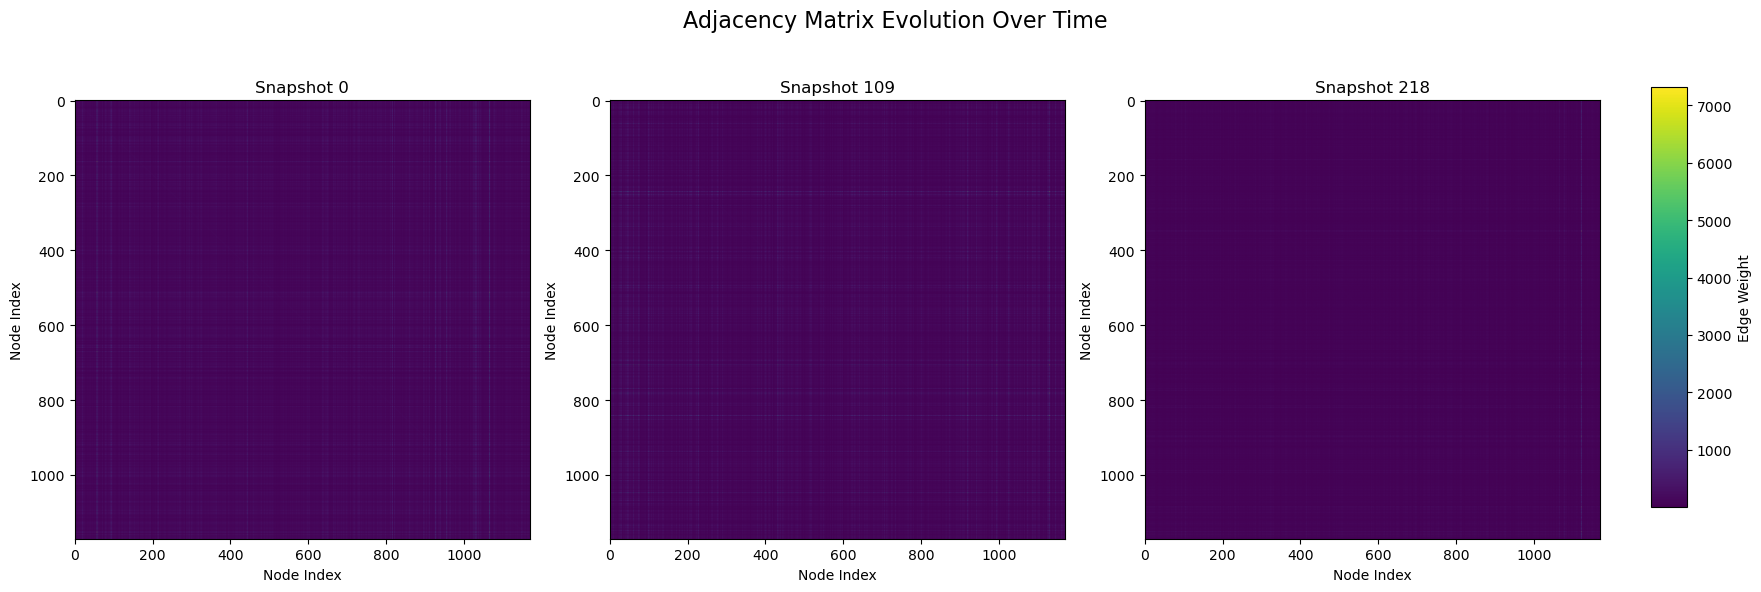

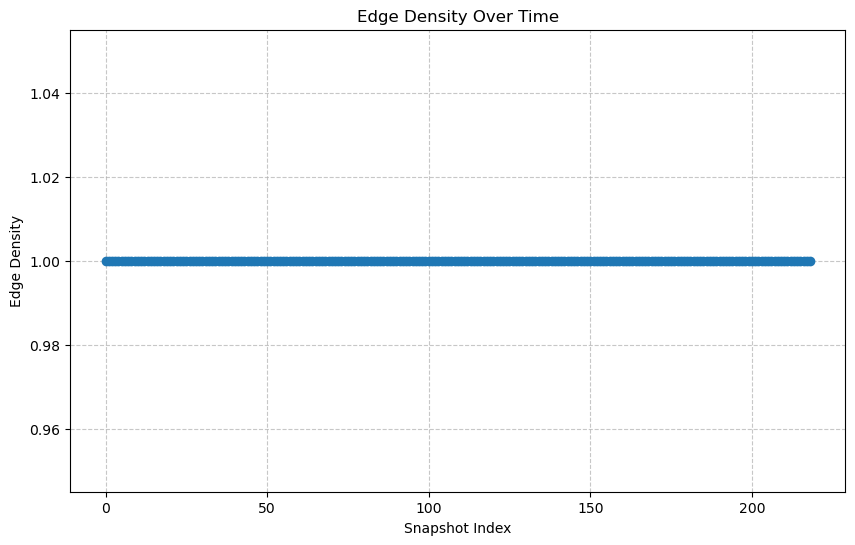

In [ ]:
# Compare adjacency matrices at different time points
if len(adj_matrices) >= 3:
    snapshot_indices = [0, len(adj_matrices)//2, len(adj_matrices)-1]  # First, middle, last
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i, idx in enumerate(snapshot_indices):
        im = axes[i].imshow(adj_matrices[idx], cmap='viridis', aspect='auto')
        axes[i].set_title(f'Snapshot {idx}')
        axes[i].set_xlabel('Node Index')
        axes[i].set_ylabel('Node Index')
    
    # Add colorbar to the right of the last image
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Edge Weight')
    
    plt.suptitle('Adjacency Matrix Evolution Over Time', fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.show()
    
    # Analyze how edge density changes over time
    edge_density = [np.count_nonzero(adj)/adj.size for adj in adj_matrices]
    plt.figure(figsize=(10, 6))
    plt.plot(edge_density, 'o-')
    plt.title('Edge Density Over Time')
    plt.xlabel('Snapshot Index')
    plt.ylabel('Edge Density')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

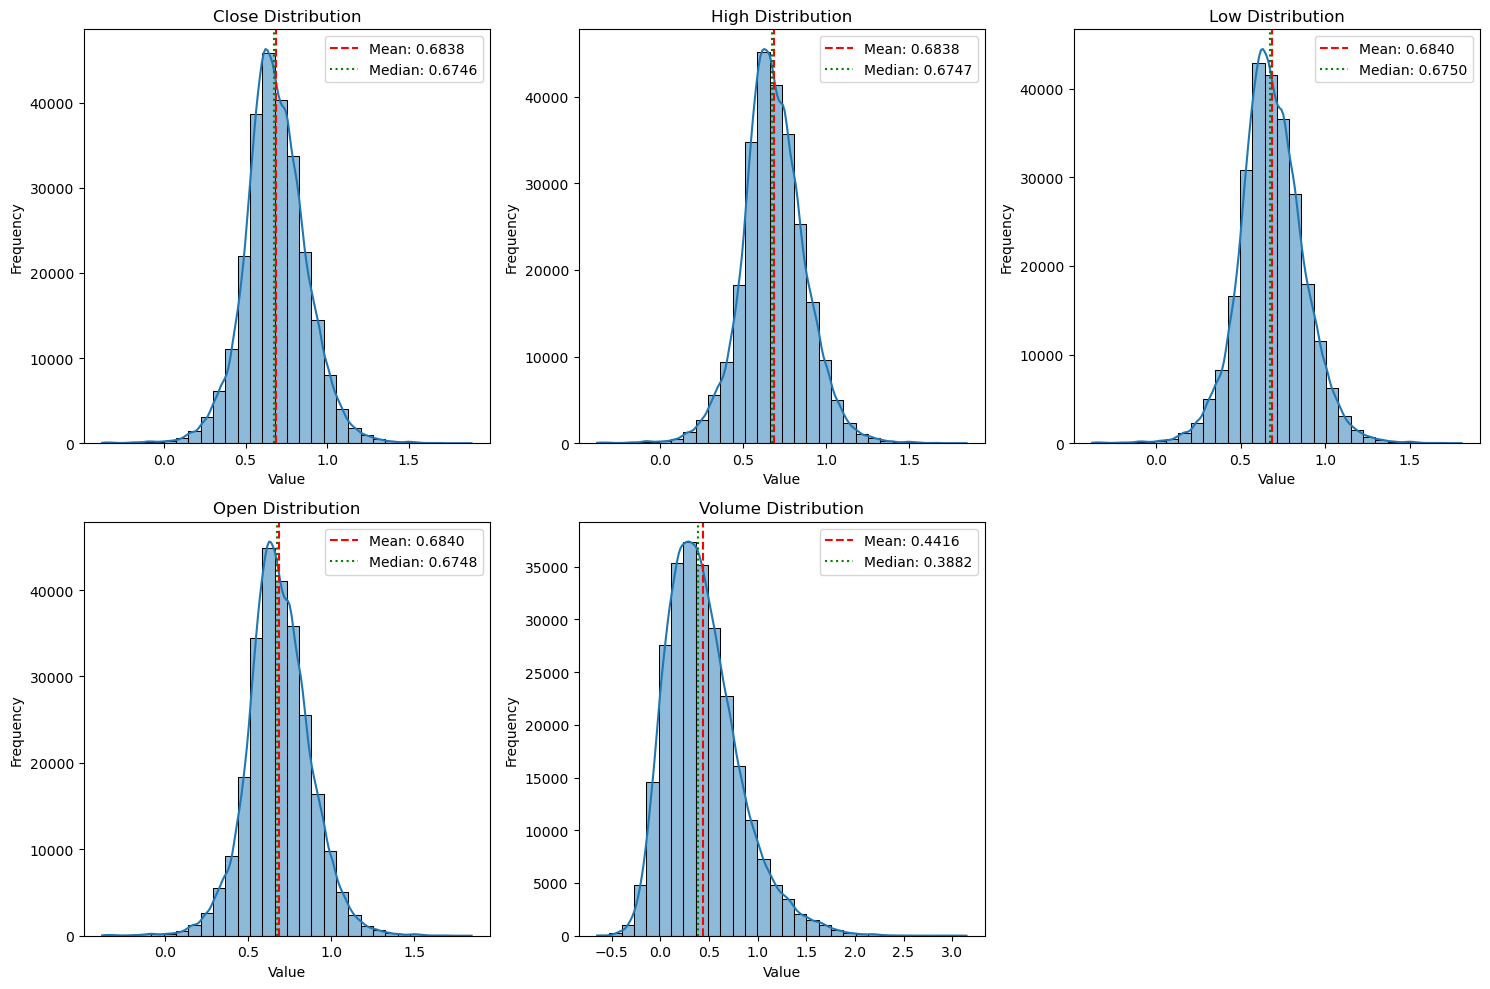

,Close,High,Low,Open,Volume
count,256449.000000,256449.000000,256449.000000,256449.000000,256449.000000
mean,0.683789,0.683782,0.684008,0.684013,0.441603
std,0.191508,0.190805,0.192015,0.191616,0.380908
min,-0.377504,-0.377876,-0.378200,-0.380427,-0.650100
25%,0.567065,0.567889,0.566376,0.567001,0.169529
50%,0.674627,0.674717,0.674971,0.674819,0.388195
75%,0.800074,0.799249,0.800791,0.800218,0.652546
max,1.882572,1.843889,1.807249,1.843962,3.147901


In [ ]:
# Get raw feature data for analysis
train_features_df = train_analyzer.analyze_node_features()

# Plot distribution of each feature
plt.figure(figsize=(15, 10))
for i, feature in enumerate(train_analyzer.features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(train_features_df[feature], kde=True, bins=30)
    plt.title(f'{feature} Distribution')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    # Add mean and median lines
    plt.axvline(train_features_df[feature].mean(), color='red', linestyle='--', 
                label=f'Mean: {train_features_df[feature].mean():.4f}')
    plt.axvline(train_features_df[feature].median(), color='green', linestyle=':', 
                label=f'Median: {train_features_df[feature].median():.4f}')
    plt.legend()
plt.tight_layout()
plt.show()

# Calculate summary statistics for features
feature_stats_df = train_features_df[train_analyzer.features].describe()
feature_stats_df

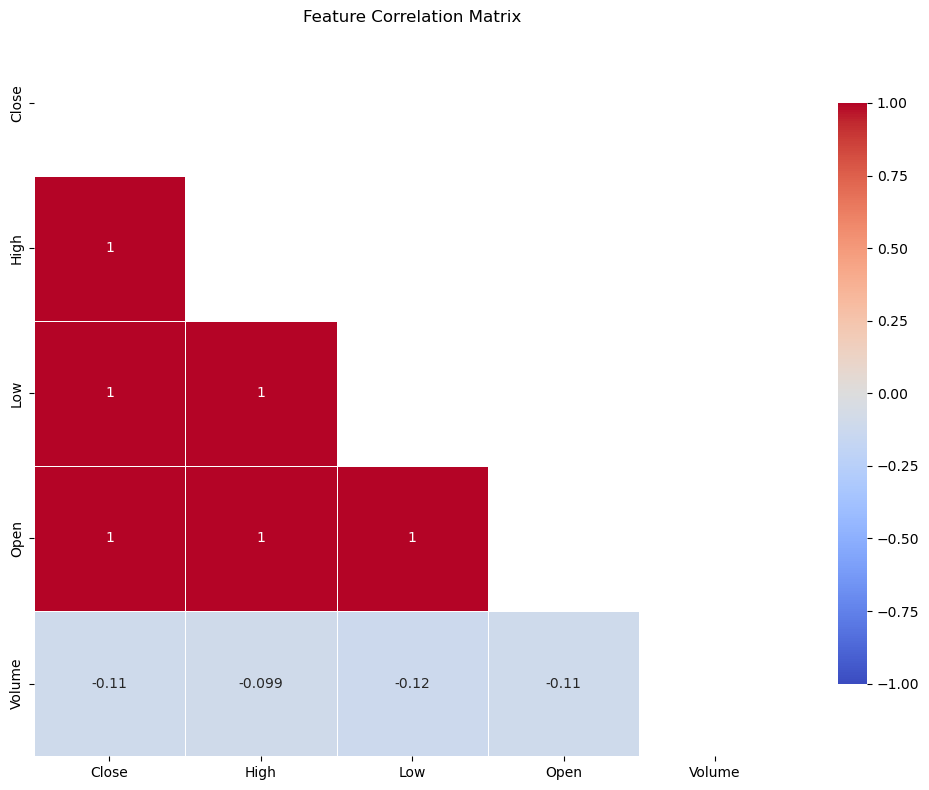

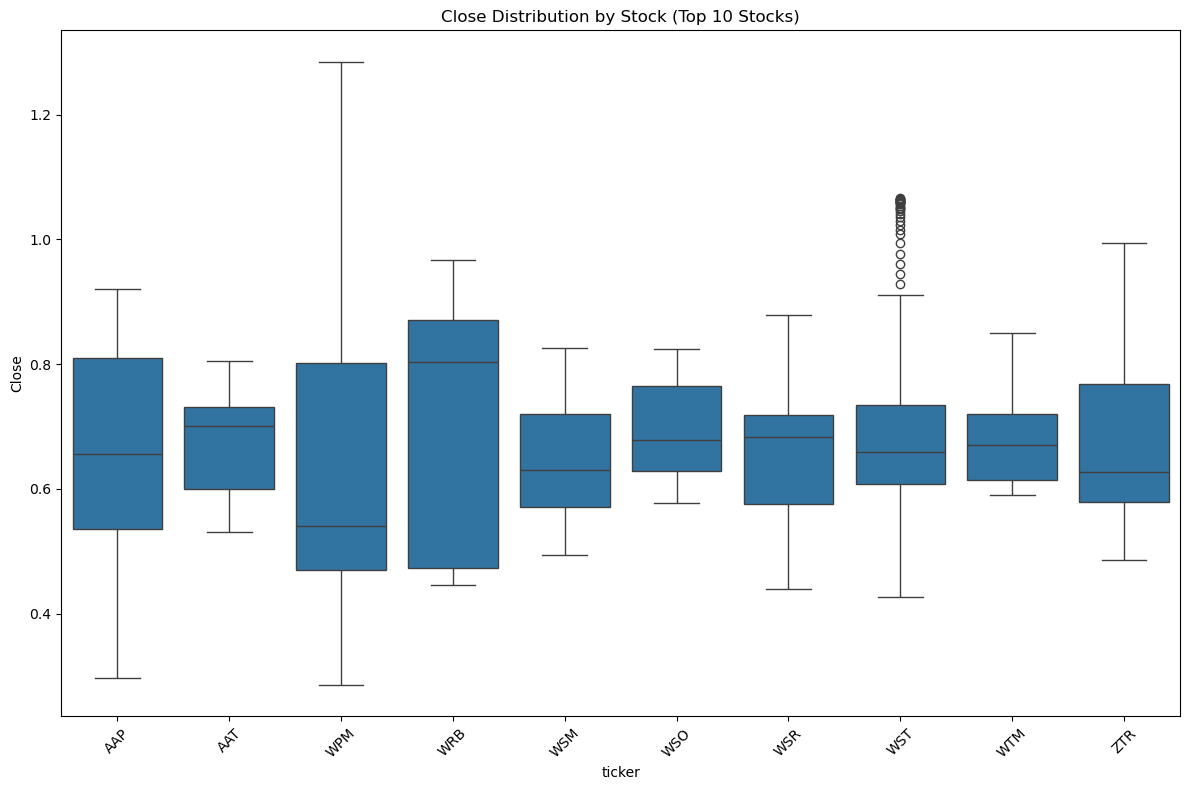

In [ ]:
# Analyze correlations between features
plt.figure(figsize=(10, 8))
corr_matrix = train_features_df[train_analyzer.features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
           linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Analyze how features vary by ticker (showing top 10 stocks for clarity)
top_stocks = train_features_df['ticker'].value_counts().head(10).index.tolist()
top_stocks_data = train_features_df[train_features_df['ticker'].isin(top_stocks)]

plt.figure(figsize=(12, 8))
feature_to_plot = 'Close'  # You can change this to any feature
sns.boxplot(x='ticker', y=feature_to_plot, data=top_stocks_data)
plt.xticks(rotation=45)
plt.title(f'{feature_to_plot} Distribution by Stock (Top 10 Stocks)')
plt.tight_layout()
plt.show()

## Homophily Analysis
Calculate and visualize homophily for each snapshot (fraction of edges connecting nodes with the same label).

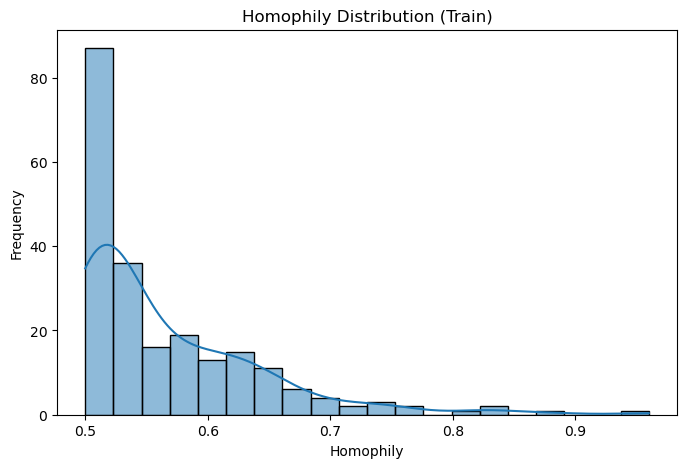

In [ ]:
homophily_scores = []

analyzer = train_analyzer

for sample_idx in range(len(analyzer.graph_snapshots)):
    homophily_score = analyzer.get_homophily_score(sample_idx)
    homophily_scores.append(homophily_score)


plt.figure(figsize=(8, 5))
sns.histplot(homophily_scores, bins=20, kde=True)
plt.title('Homophily Distribution (Train)')
plt.xlabel('Homophily')
plt.ylabel('Frequency')
plt.show()

## Feature-Target Correlation Analysis
Analyze the relationship between node features and their corresponding labels (up/down movement).

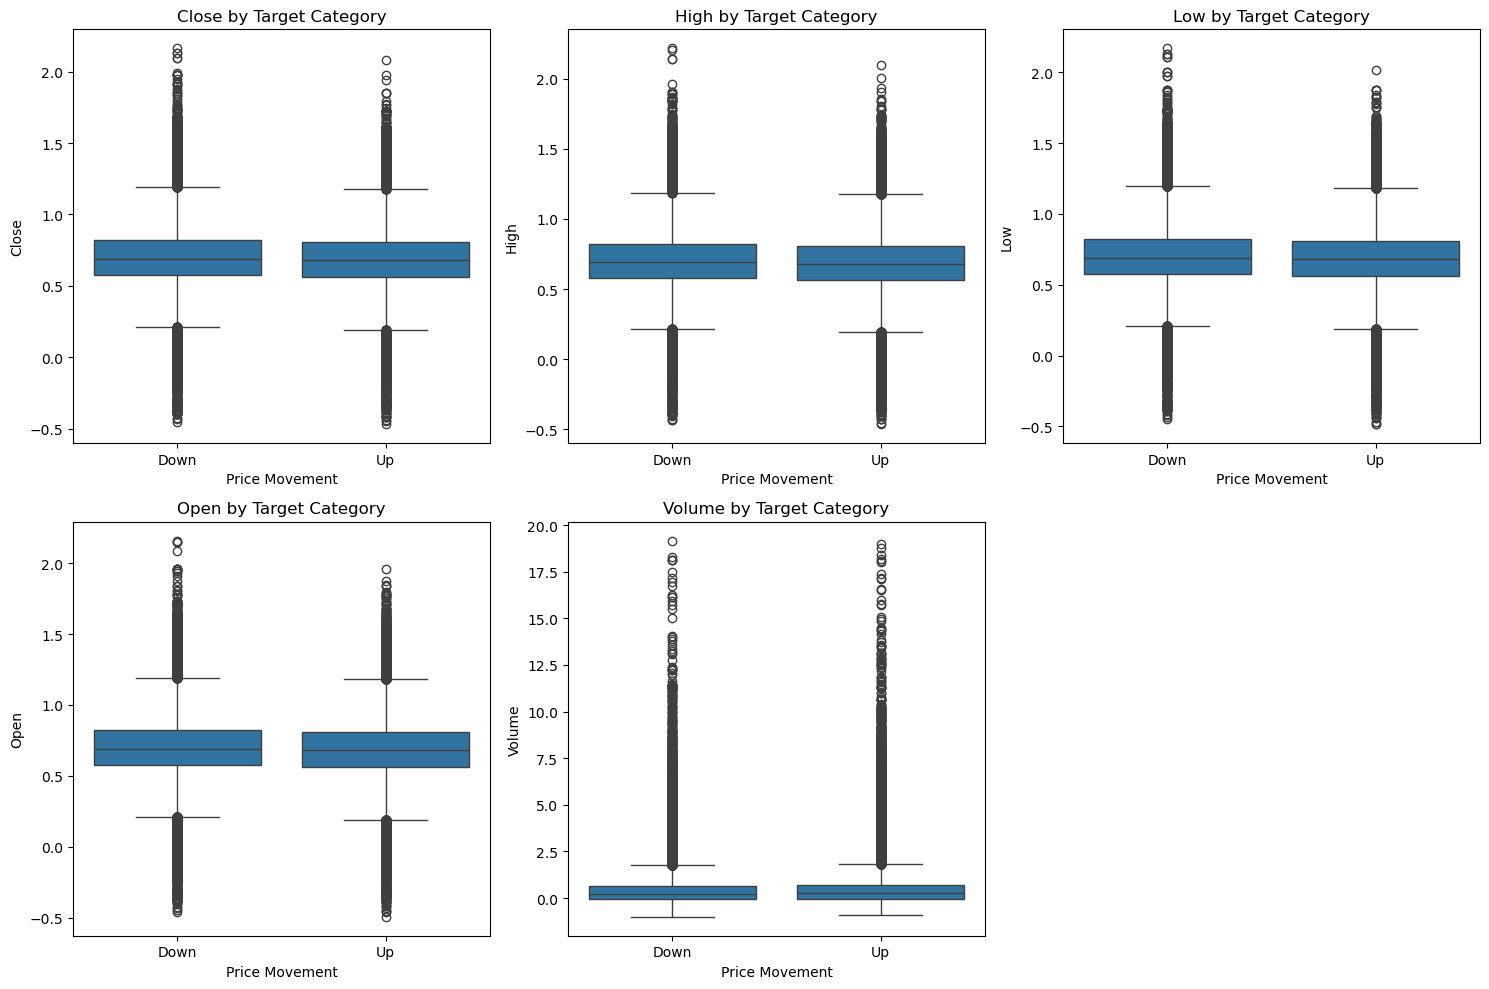

Average feature values by target category:


,Close,High,Low,Open,Volume
target_category,,,,,
Down,0.703105,0.702563,0.703291,0.703003,0.427207
Up,0.685857,0.686535,0.686209,0.686736,0.463443


In [ ]:
# Collect features and labels from snapshots
features_list = []
labels_list = []

for i in range(train_analyzer.num_snapshots):
    snapshot = train_analyzer.graph_snapshots[i]
    features = snapshot.x
    
    # Handle different feature shapes
    if features.dim() == 3:
        # Take the last time step for each node
        features = features[:, -1, :] 
    elif features.dim() == 2 and features.shape[1] > train_analyzer.num_features:
        # Reshape if needed
        features = features.reshape(features.shape[0], -1, train_analyzer.num_features)
        features = features[:, -1, :]
    
    features_np = features.numpy()
    labels_np = snapshot.y.numpy()
    
    features_list.append(features_np)
    labels_list.append(labels_np)

# Combine all snapshots
all_features = np.vstack(features_list)
all_labels = np.hstack(labels_list)

# Create a DataFrame with features and labels
feature_target_df = pd.DataFrame(all_features, columns=train_analyzer.features)
feature_target_df['target'] = all_labels
feature_target_df['target_category'] = np.where(feature_target_df['target'] > 0, 'Up', 'Down')

# Visualize feature distributions by target category
plt.figure(figsize=(15, 10))
for i, feature in enumerate(train_analyzer.features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='target_category', y=feature, data=feature_target_df)
    plt.title(f'{feature} by Target Category')
    plt.xlabel('Price Movement')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

# Calculate mean values by target category
feature_by_target = feature_target_df.groupby('target_category')[train_analyzer.features].mean()
print("Average feature values by target category:")
display(feature_by_target)

## Up Ratios Analysis
Visualize the distribution of up ratios (fraction of nodes with positive label) for each dataset.

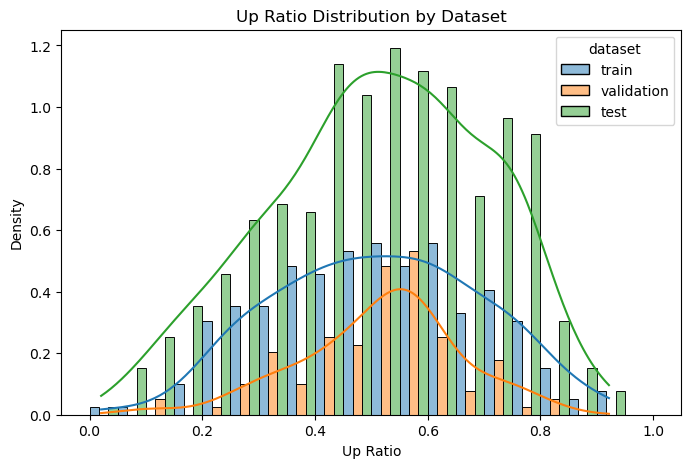

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=all_snapshots_df, x='up_ratio', hue='dataset', multiple='dodge', kde=True, binrange=(0, 1), binwidth=.05, stat='density')
plt.title('Up Ratio Distribution by Dataset')
plt.xlabel('Up Ratio')
plt.ylabel('Density')
plt.show()

## Connectivity Analysis
Compare connectivity statistics across datasets.

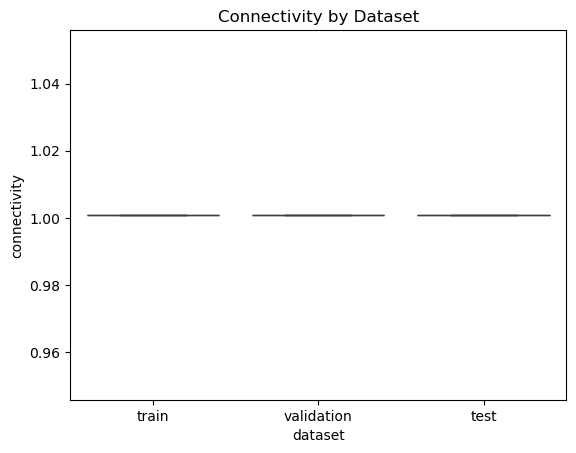

In [ ]:
sns.boxplot(data=all_snapshots_df, x='dataset', y='connectivity')
plt.title('Connectivity by Dataset')
plt.show()

## Summary Statistics
Show summary statistics for key metrics in each dataset.

In [ ]:
summary = all_snapshots_df.groupby('dataset')[['up_ratio', 'connectivity']].describe()
summary

up_ratio                                                    \
              count      mean       std       min       25%       50%   
dataset                                                                 
test          469.0  0.513060  0.191232  0.023057  0.385141  0.518360   
train         219.0  0.511158  0.181491  0.020495  0.377028  0.509821   
validation    101.0  0.515731  0.140370  0.102477  0.436379  0.528608   

                               connectivity                                    \
                 75%       max        count      mean           std       min   
dataset                                                                         
test        0.654996  0.921435        469.0  1.000855  8.668987e-15  1.000855   
train       0.642186  0.911187        219.0  1.000855  4.228513e-15  1.000855   
validation  0.593510  0.812980        101.0  1.000855  1.562064e-15  1.000855   

                                                    
                 25%       50%       75%       max  
dataset                                             
test        1.000855  1.000855  1.000855  1.000855  
train       1.000855  1.000855  1.000855  1.000855  
validation  1.000855  1.000855  1.000855  1.000855

## Dataset Analysis Summary

This comprehensive analysis of the temporal graph datasets reveals several key insights:

### Adjacency Matrix Insights
- **Edge weights**: The edge weights in our adjacency matrices represent correlation strengths between stock price movements
- **Density**: We've analyzed the edge density across snapshots and observed its temporal evolution
- **Distribution**: The distribution of edge weights provides insights into the overall market connectivity

### Node Feature Insights
- **Feature distributions**: We've analyzed the statistical properties of node features across all snapshots
- **Feature correlations**: We've identified correlations between different features
- **Feature-target relationships**: We've examined how features differ between stocks with positive and negative price movements

### Graph Structure Insights
- **Homophily**: We've measured the tendency of connected stocks to have the same price movement direction
- **Connectivity**: We've compared connectivity across different datasets and time periods
- **Up ratio distribution**: We've analyzed the balance between positive and negative price movements across datasets

This analysis provides a solid foundation for understanding the datasets used in our temporal graph neural network models.